<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/9_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Plain Networks vs Residual Network

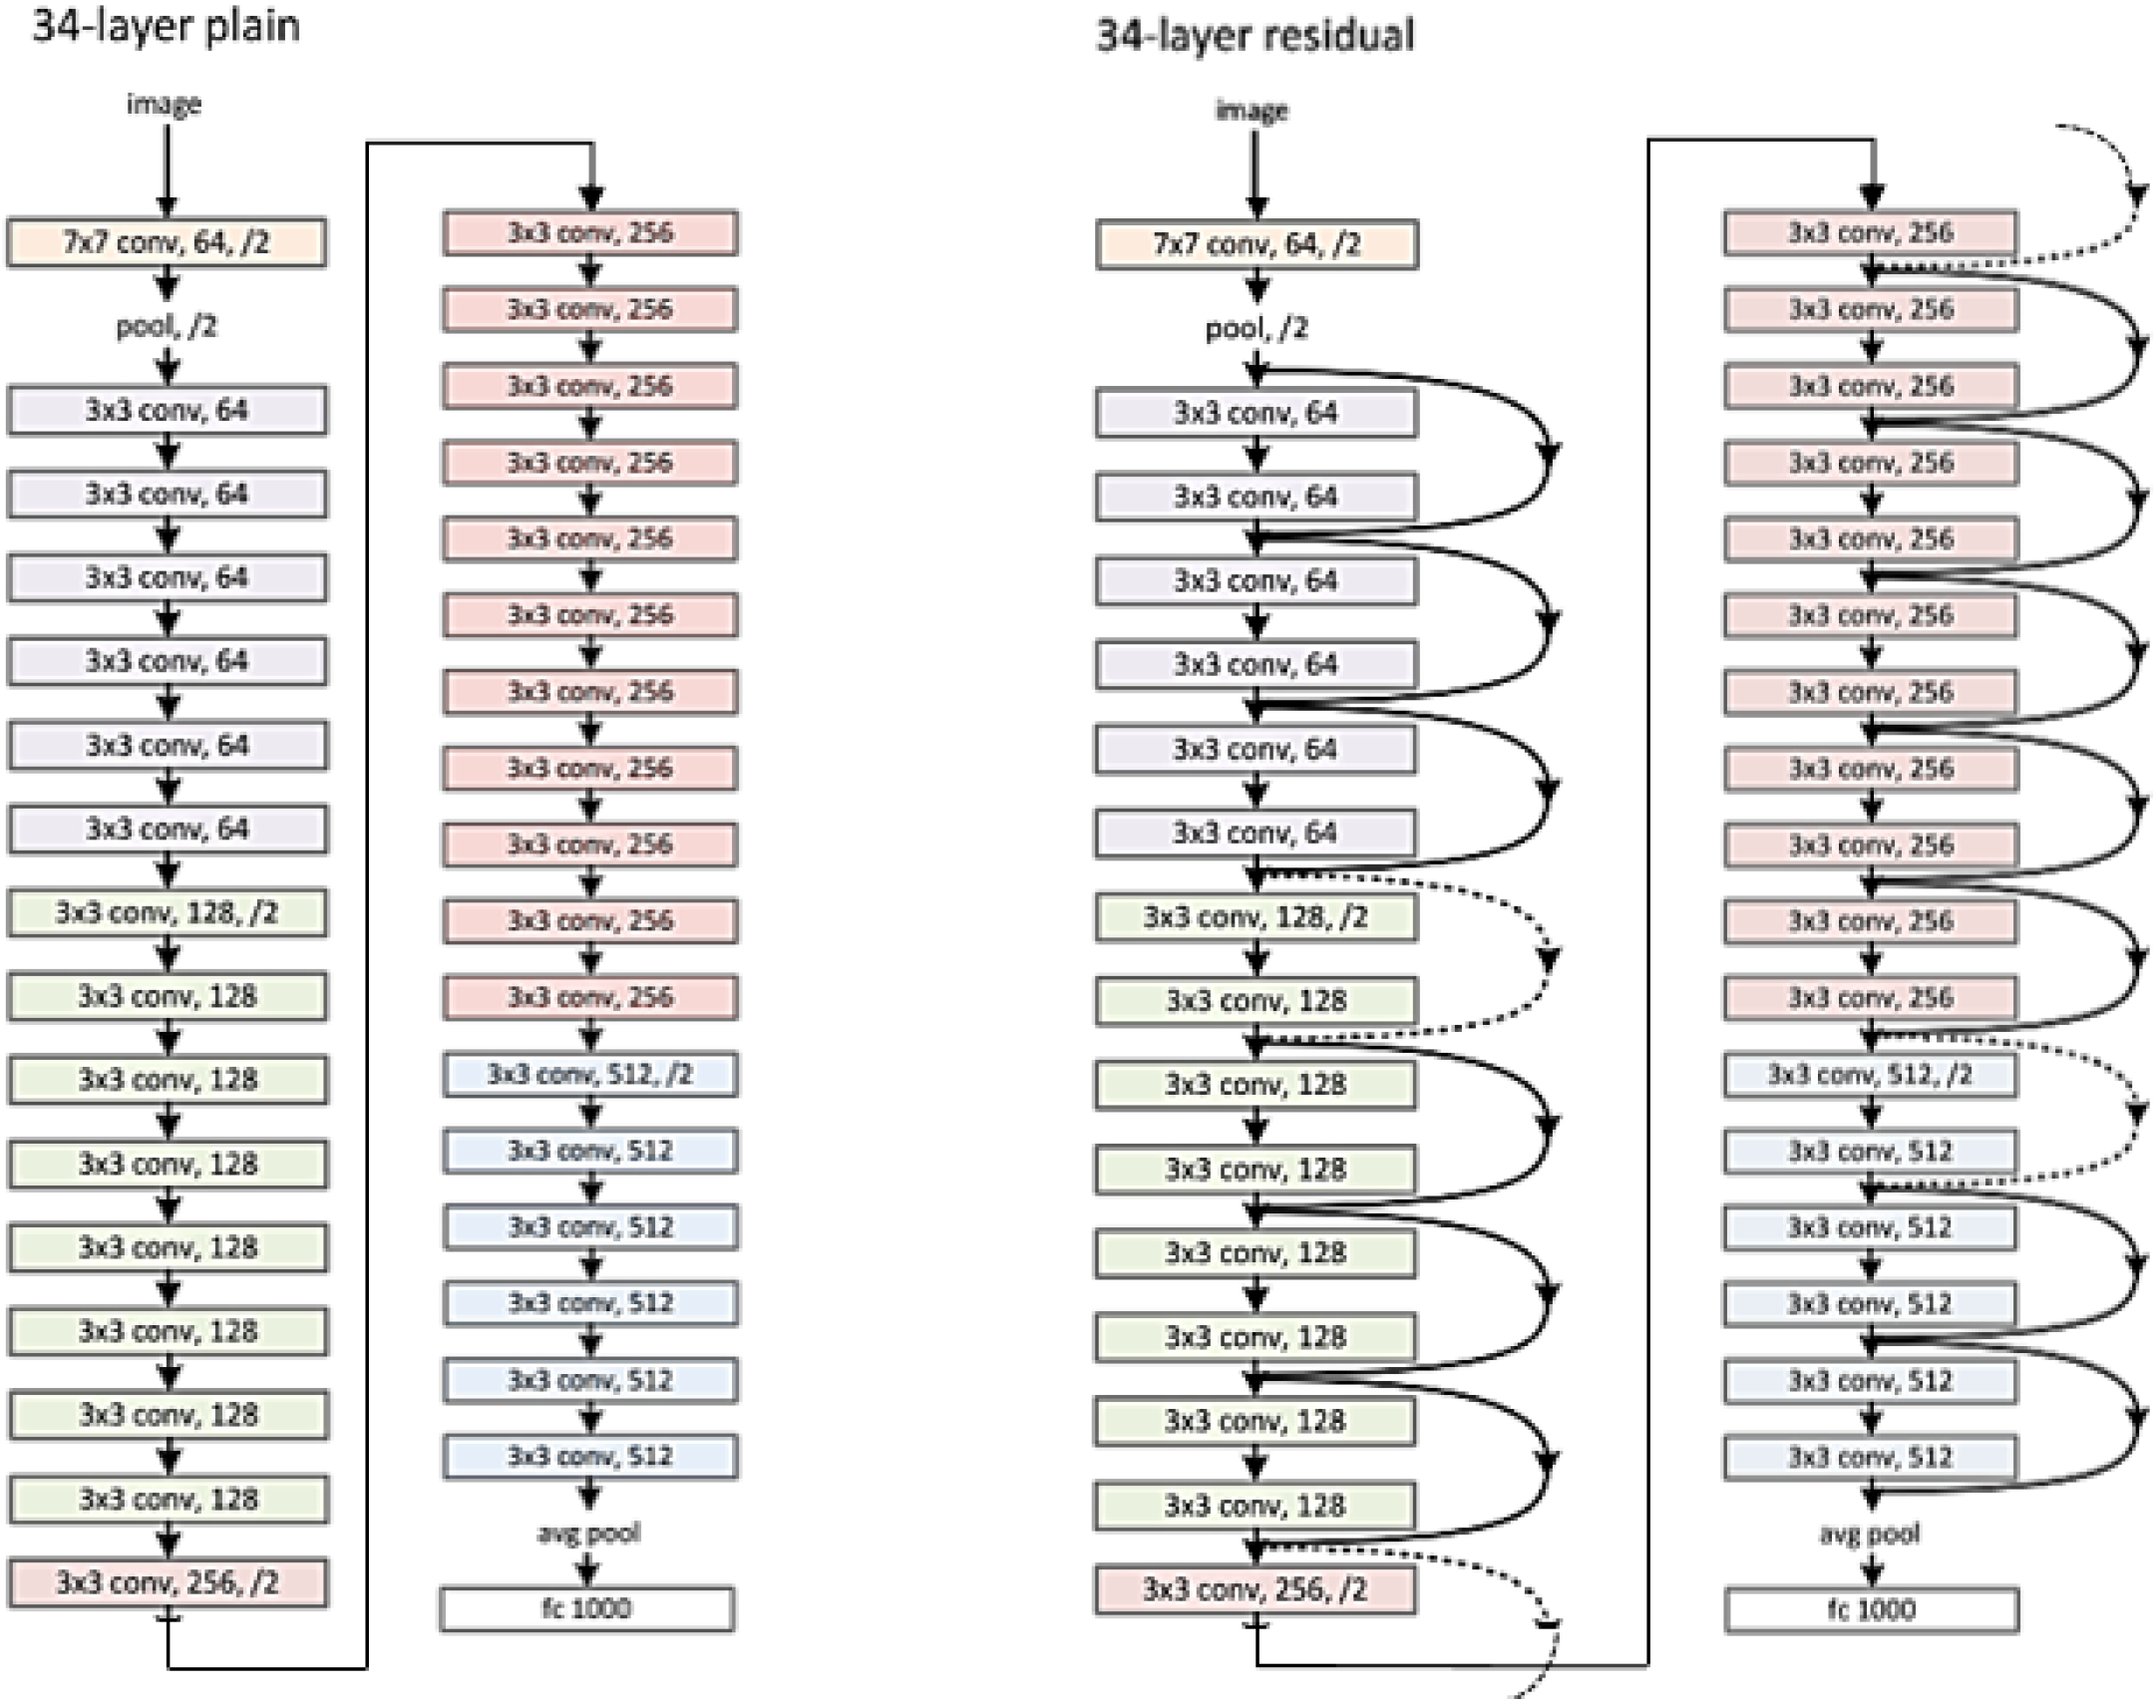

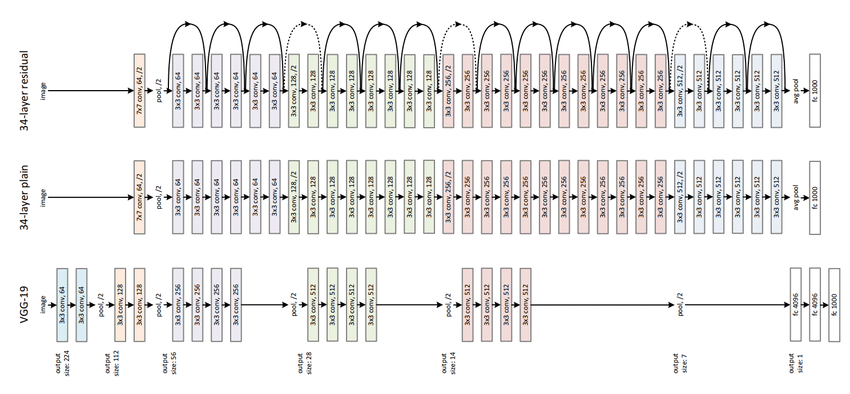

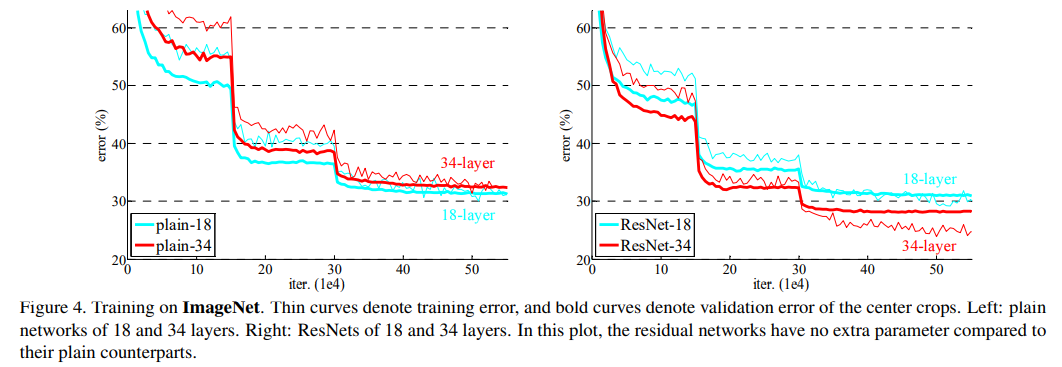


Resnet 34 has low error as compared to Resnet 18 so deep neural network works perfectly well with Resnet


## Resnet 50

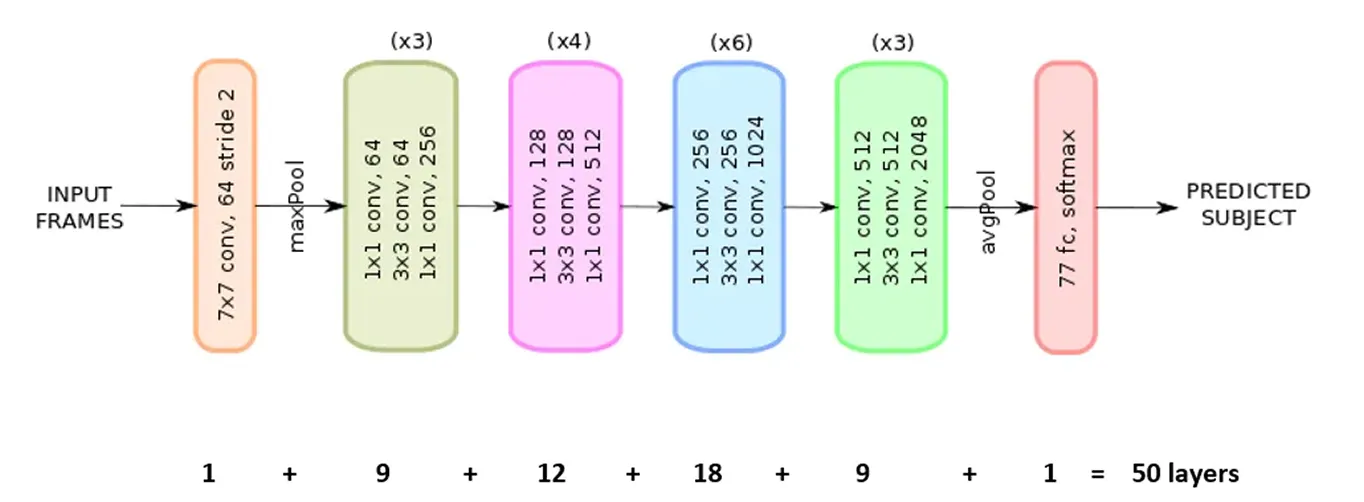

## Importing the dataset

In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_5aff8763a11c2fb1654d67dea213a0df"

In [3]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 10.7 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [4]:
!kaggle datasets download -d samuelcortinhas/sports-balls-multiclass-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
License(s): CC0-1.0
100% 401M/401M [00:03<00:00, 125MB/s]



In [5]:
!unzip /content/sports-balls-multiclass-image-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/cricket_ball/cricket_ball_182.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_183.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_185.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_186.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_187.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_189.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_19.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_190.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_191.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_192.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_195.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_196.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_199.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_200.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_

## Importing Packages

In [6]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Rescaling

import tensorflow as tf
import os

# For reproducibility
import numpy as np
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

seed=123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

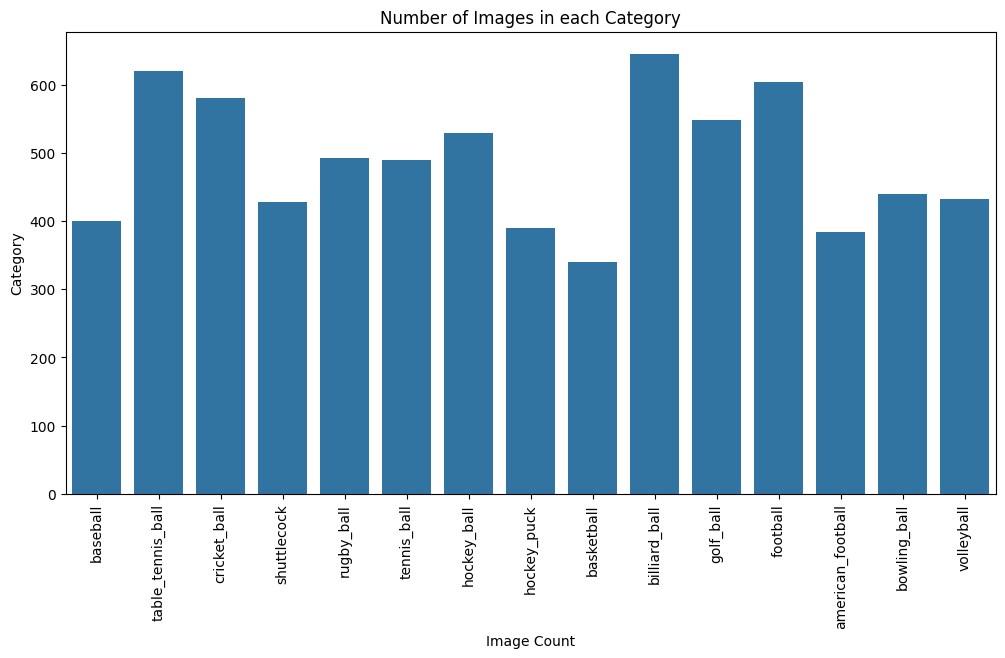

In [7]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Train Directory path
train_dir='/content/train'

# Dictionary to store subdirectory names and file counts
data={'Category':[],'Image Count':[]}

# Loop through each subdirectory
for sub_dir in os.listdir(train_dir):
    sub_dir_path=os.path.join(train_dir, sub_dir)
    if os.path.isdir(sub_dir_path):
        # Count the no. of files(imgs) in subdirectory
        num_files=len([f for f in os.listdir(sub_dir_path) if os.path.isfile(os.path.join(sub_dir_path,f))])
        data['Category'].append(sub_dir)
        data['Image Count'].append(num_files)

# Convert the data to a pandas Dataframe
df=pd.DataFrame(data)

# Create the barplot using Seaborn
plt.figure(figsize=(12,6))
sns.barplot(x='Category', y='Image Count', data=df)
plt.xticks(rotation=90)
plt.title('Number of Images in each Category')
plt.xlabel('Image Count')
plt.ylabel('Category')
plt.show()

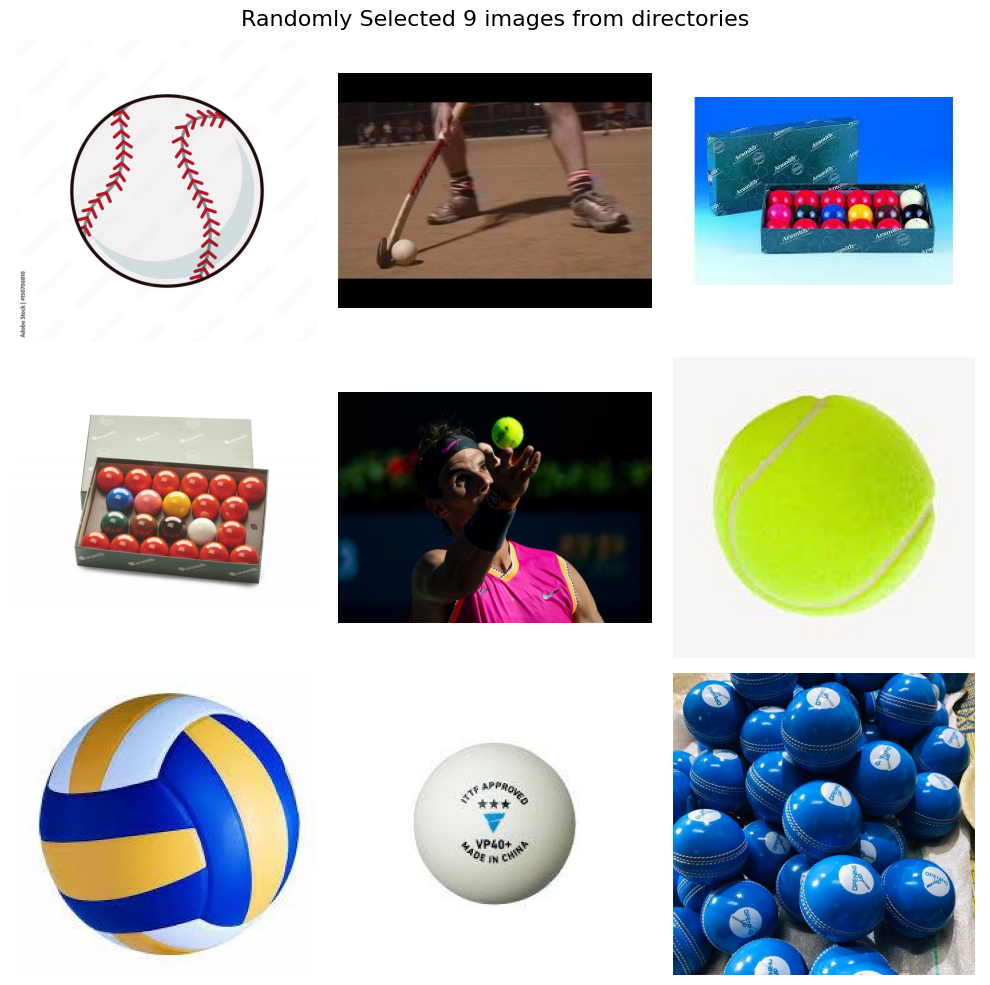

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory path
train_dir='/content/train'

# Get all subdirectories and files in the directories
all_images=[]
for sub_dir in os.listdir(train_dir):
    sub_dir_path=os.path.join(train_dir, sub_dir)
    if os.path.isdir(sub_dir_path):
        all_images.extend([os.path.join(sub_dir_path,f) for f in os.listdir(sub_dir_path) if os.path.isfile(os.path.join(sub_dir_path,f))])

# Randomly selected 9 imgs
random_images=random.sample(all_images,9)

# Plotting the images in 3X3 grid
plt.figure(figsize=(10,10))
for i, image_path in enumerate(random_images):
    img=mpimg.imread(image_path)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('Randomly Selected 9 images from directories', fontsize=16)
plt.tight_layout()
plt.show()

## Data Preparation

In [10]:
# Setting up dir and parameters
train_dir='/content/train'
img_size=(224,224)     # Resnet50 std input size
batch_size=32          # Adjust batch size as per gpu capacity

In [12]:
# Data Augmentation Layers(applied during training)
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip('horizontal'),   # Random horizontal flip
    layers.RandomRotation(0.1),         # Random Rotation
    layers.RandomZoom(0.1),             # Random Zoom
])

In [14]:
# Load training and validation datasets using image_dataset_from_directory
train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.


In [16]:
validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    labels='inferred',
    label_mode='categorical',
    subset='validation',
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 1465 files for validation.


In [17]:
# Applying data augmentation only on the training data
train_dataset=train_dataset.map(lambda x,y: (data_augmentation(x,training=True),y))

In [18]:
# Optional: Prefetch data for performance improvememt
AUTOTUNE=tf.data.experimental.AUTOTUNE
train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset=validation_dataset.prefetch(buffer_size=AUTOTUNE)

## Model Building

In [19]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut=x

    # First 1X1 Conv to reduce dim
    x=layers.Conv2D(filters,kernel_size=1,strides=stride,padding='same')(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)

    # Second 3X3 Conv
    x=layers.Conv2D(filters,kernel_size=kernel_size,strides=1,padding='same')(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)

    # Third 1X1 Conv to restore dim
    x=layers.Conv2D(filters*4,kernel_size=1,strides=1,padding='same')(x)
    x=layers.BatchNormalization()(x)

    # Shortcut connection(adjust dim if necessary)
    if stride!= 1 or shortcut.shape[-1] !=filters*4:
        shortcut=layers.Conv2D(filters*4,kernel_size=1,strides=stride,padding='same')(shortcut)
        shortcut=layers.BatchNormalization()(shortcut)

    # Add the shortcut
    x=layers.Add()([x, shortcut])
    x=layers.Activation('relu')(x)
    return x

## Resnet different layers

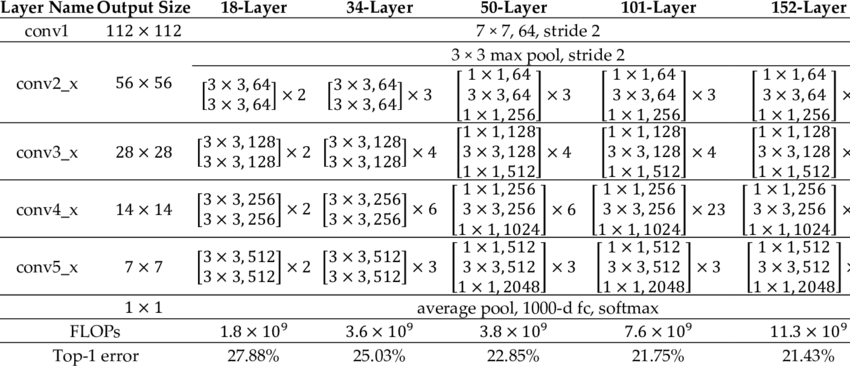

In [22]:
def build_resnet50(input_shape=(224,224,3), num_classes=15):
    inputs=tf.keras.Input(shape=input_shape)

    # x=layers.rescaling(1/255.)

    # Initial Conv and MaxPooling
    x=layers.Conv2D(64,kernel_size=7,strides=2,padding='same')(inputs)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)
    x=layers.MaxPooling2D(pool_size=3,strides=2,padding='same')(x)

    # Residual Blocks: (for skip connections bottlenet architecture)
    x=residual_block(x,filters=64)
    x=residual_block(x,filters=64)
    x=residual_block(x,filters=64)

    x=residual_block(x,filters=128,stride=2)
    x=residual_block(x,filters=128)
    x=residual_block(x,filters=128)
    x=residual_block(x,filters=128)

    x=residual_block(x,filters=256,stride=2)
    x=residual_block(x,filters=256)
    x=residual_block(x,filters=256)
    x=residual_block(x,filters=256)
    x=residual_block(x,filters=256)
    x=residual_block(x,filters=256)

    x=residual_block(x,filters=512,stride=2)
    x=residual_block(x,filters=512)
    x=residual_block(x,filters=512)

    # Global Average Pooling and Output
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dense(num_classes, activation='softmax')(x)

    model=models.Model(inputs,x)
    return model

In [23]:
# Building the model
model=build_resnet50(input_shape=(224,224,3))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 56, 56,    │      4,160 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_11[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 56, 56,    │     16,640 │ activation_12[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 56, 56,    │     16,640 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 56, 56,    │          0 │ add_3[0][0]     

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 23,565,327 (89.89 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
# Train the model
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 212s 812ms/step - accuracy: 0.1598 - loss: 2.6482 - val_accuracy: 0.0990 - val_loss: 3.4177
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 118s 639ms/step - accuracy: 0.2342 - loss: 2.4279 - val_accuracy: 0.1502 - val_loss: 2.9115
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 118s 638ms/step - accuracy: 0.2688 - loss: 2.3124 - val_accuracy: 0.1904 - val_loss: 2.7914
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 99s 536ms/step - accuracy: 0.3019 - loss: 2.2094 - val_accuracy: 0.1823 - val_loss: 2.7334
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 97s 526ms/step - accuracy: 0.3398 - loss: 2.1040 - val_accuracy: 0.2287 - val_loss: 2.6274


## Pretrained model in Keras library and Fine Tuning

In [27]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Setting up directory and parameters
train_dir='/content/train'
img_size=(224,224)
batch_size=32
num_classes=15

# Load the pretrained ResNet50 model excluding the top layers
base_model=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [30]:
# Freeze the base model layers
base_model.trainable=False

# Create a new model on top of the pre-trained base model
inputs=tf.keras.Input(shape=(224,224,3))

# Normalization layer
x=layers.Rescaling(1./255)(inputs)


# Optional : Data Augmentation Layers(if needed)
#x=layers.RandomFlip('horizontal')(x),   # Random horizontal flip
#x=layers.RandomRotation(0.1)(x),         # Random Rotation
#x=layers.RandomZoom(0.1)(x),             # Random Zoom

# Pass the inputs through the pre-trained ResNet50 base model
x=base_model(x,training=False)

# Global avg Pooling to reduce the output top a single vector per image
x=layers.GlobalAveragePooling2D()(x)

# Add a fully connected layer with  the number of classes
x=layers.Dense(256,activation='relu')(x)
x=layers.Dropout(0.5)(x)

# Final output layer with Softmax activation for classification
outputs=layers.Dense(num_classes,activation='softmax')(x)

# Create the final model
model=models.Model(inputs,outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [32]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Load training and validation datasets using image_dataset_from_directory
train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Prefetch data for performance improvememt
AUTOTUNE=tf.data.experimental.AUTOTUNE
train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset=validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Train the new layers while keeping the base model frozen
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.
Found 7328 files belonging to 15 classes.
Using 1465 files for validation.
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 61s 261ms/step - accuracy: 0.0843 - loss: 2.8358 - val_accuracy: 0.1345 - val_loss: 2.6298
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 34s 183ms/step - accuracy: 0.1221 - loss: 2.6545 - val_accuracy: 0.1331 - val_loss: 2.6060
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 176ms/step - accuracy: 0.1346 - loss: 2.6170 - val_accuracy: 0.1652 - val_loss: 2.5793
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - accuracy: 0.1375 - loss: 2.5971 - val_accuracy: 0.1652 - val_loss: 2.5650
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.1520 - loss: 2.5799 - val_accuracy: 0.1693 - val_loss: 2.5490


## Layer Fine Tuning


In [33]:
# Load the pretrained ResNet50 model excluding the top layers
base_model=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Unfreeze the last few layers of the base model for fine tuning
base_model.trainable=True

# Let's setup how many layers we want to fine tune
# For example we can choose to fine tune the last 10 layers of the base model
fine_tune_at=140 # Unfreeze from this layeer onwards

# Freeze all layers before 'fine_tune_at'
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable=False

# Conpile the model again after unfreezing layers (lower learning rate for fine tuning)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
fine_tune_history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 180ms/step - accuracy: 0.1542 - loss: 2.5649 - val_accuracy: 0.1939 - val_loss: 2.5431
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.1663 - loss: 2.5504 - val_accuracy: 0.1945 - val_loss: 2.5408
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.1562 - loss: 2.5495 - val_accuracy: 0.1911 - val_loss: 2.5384
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.1585 - loss: 2.5490 - val_accuracy: 0.1952 - val_loss: 2.5361
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.1602 - loss: 2.5464 - val_accuracy: 0.1966 - val_loss: 2.5345


In [34]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,172,911 (96.03 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,056,800 (4.03 MB)

# Assignment

- Complete te model for larger epochs
- Work and implement on new dataset
- Performance Metrics (Accuracy plot and Loss plot)
- Confusion matrix
- Model evaluation

- Do it all in custom made model
- Loading Model
- Fine tuning of Pre Trained Model